In [2]:
import torch
import pandas as pd
import numpy as np
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [23]:
"""from google.colab import files
uploaded = files.upload()"""

df = pd.read_csv(r"C:\Users\ehend\university_project_dds\Real-Estate-DDS-Project\data\cleaned_data.csv")
df.head()

,title,descriptionHtml,propertyType,sizeSqFeetMax,bedrooms,bathrooms,listingUpdateReason,price,id,date_field,...,street,area,postcode,latitude,longitude,district,ward,constituency,distance_to_tube,crime_count
0,"8 bedroom house for sale in Winnington Road, H...","This magnificent home, set behind security gat...",House,16749.0,8.0,8.0,new,24950000.0,d189cb20-3fb1-4173-987a-9cb6b2b74117,10/10/2024,...,Winnington Road,Hampstead,N2,51.586178,-0.170121,Barnet,Garden Suburb,Finchley and Golders Green,0.393045,251.0
1,"7 bedroom house for sale in Brick Street, Mayf...","In the heart of exclusive Mayfair, this majest...",House,12960.0,7.0,7.0,price_reduced,29500000.0,df2bfee7-8ce8-4690-b718-31606ccdc0c1,24/10/2024,...,Brick Street,Mayfair,W1J,51.509539,-0.136100,Westminster,West End,Cities of London and Westminster,0.166217,8654.0
2,6 bedroom terraced house for sale in Chester S...,A freehold home that gives you everything you ...,Terraced,6952.0,6.0,6.0,price_reduced,25000000.0,8c8bc78a-c39f-44f3-8694-a55e51c559b5,22/02/2024,...,Chester Square,Belgravia,SW1W,51.498405,-0.146841,Westminster,St James's,Cities of London and Westminster,0.299003,2564.0
3,6 bedroom detached house for sale in Winningto...,A magnificent bespoke residence set behind sec...,Detached,16749.0,6.0,6.0,new,24950000.0,6f20f033-1ee3-4fd4-808b-f6f9ab04450d,08/04/2024,...,Winnington Road,Hampstead,N2,51.586178,-0.170121,Barnet,Garden Suburb,Finchley and Golders Green,0.393045,251.0
4,8 bedroom detached house for sale in St. John'...,"With its village like ambiance, elegant regenc...",Detached,10241.0,8.0,10.0,price_reduced,24950000.0,acf404d0-001b-4007-8676-7bbc020a0aa7,11/07/2023,...,St. John's Wood,Abbey Road,NW8,51.535626,-0.181925,Westminster,Abbey Road,Cities of London and Westminster,0.671529,1348.0


In [4]:
print("Raw df:", len(df))

# Check each filter in remove_outliers
temp = df.copy()
temp = temp[temp["price"] > 0]
print("After price > 0:", len(temp))

temp = temp[temp["sizeSqFeetMax"] > 0]
print("After size > 0:", len(temp))

price_low = temp["price"].quantile(0.01)
price_high = temp["price"].quantile(0.95)
temp = temp[temp["price"].between(price_low, price_high)]
print("After price filter:", len(temp))

size_high = temp["sizeSqFeetMax"].quantile(0.99)
temp = temp[temp["sizeSqFeetMax"] <= size_high]
print("After size filter:", len(temp))

temp = temp[temp["bedrooms"] <= 20]
print("After bedrooms filter:", len(temp))

temp = temp[temp["bathrooms"] <= 20]
print("After bathrooms filter:", len(temp))

Raw df: 1019
After price > 0: 1018
After size > 0: 1018
After price filter: 958
After size filter: 948
After bedrooms filter: 922
After bathrooms filter: 920


In [5]:
temp = temp.dropna(subset=["crime_count_log", "distance_to_tube"])
print("After dropping NaN new features:", len(temp))

After dropping NaN new features: 919


In [6]:
target_col = "price"

numeric_features = [
    "sizeSqFeetMax",
    "bedrooms",
    "bathrooms",
    "latitude",
    "longitude"
]

categorical_features = [
    "property_group"
]

used_columns = numeric_features + categorical_features + [target_col]

data = df[used_columns].copy()

data.head()

,sizeSqFeetMax,bedrooms,bathrooms,latitude,longitude,property_group,price
0,16749.0,8.0,8.0,51.586178,-0.170121,House,24950000.0
1,12960.0,7.0,7.0,51.509539,-0.136100,House,29500000.0
2,6952.0,6.0,6.0,51.498405,-0.146841,Terraced House,25000000.0
3,16749.0,6.0,6.0,51.586178,-0.170121,Detached House,24950000.0
4,10241.0,8.0,10.0,51.535626,-0.181925,Detached House,24950000.0


In [7]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

In [8]:
def remove_outliers(data):
    data = data.copy()

    data = data[data["price"] > 0]
    data = data[data["sizeSqFeetMax"] > 0]

    price_low = data["price"].quantile(0.01)
    price_high = data["price"].quantile(0.95)
    size_high = data["sizeSqFeetMax"].quantile(0.99)

    data = data[
        (data["price"] >= price_low) &
        (data["price"] <= price_high) &
        (data["sizeSqFeetMax"] <= size_high) &
        (data["bedrooms"] <= 10) &
        (data["bathrooms"] <= 10)
    ]

    return data


def add_custom_features(data):
    data = data.copy()

    size = data["sizeSqFeetMax"].replace(0, np.nan)

    data["log_sizeSqFeetMax"] = np.log1p(data["sizeSqFeetMax"])
    data["sizeSqFeetMax_squared"] = data["sizeSqFeetMax"] ** 2

    data["bedrooms_squared"] = data["bedrooms"] ** 2
    data["bathrooms_squared"] = data["bathrooms"] ** 2

    data["bedrooms_x_bathrooms"] = data["bedrooms"] * data["bathrooms"]

    data["bedrooms_per_1000_sqft"] = data["bedrooms"] / (size / 1000)
    data["bathrooms_per_1000_sqft"] = data["bathrooms"] / (size / 1000)

    data["rooms_total"] = data["bedrooms"] + data["bathrooms"]
    data["rooms_per_1000_sqft"] = data["rooms_total"] / (size / 1000)

    return data


def build_modeling_data(
    df,
    numeric_features,
    categorical_features,
    use_outlier_removal=False,
    add_engineered_features=False
):
    data = df.copy()

    important_numeric_cols = [
        "price",
        "sizeSqFeetMax",
        "bedrooms",
        "bathrooms",
        "latitude",
        "longitude"
    ]

    for col in important_numeric_cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

    data = data.dropna(subset=["price"])
    data = data[data["price"] > 0]

    if add_engineered_features:
        data = add_custom_features(data)

    used_columns = numeric_features + categorical_features + [target_col]
    data = data[used_columns].copy()

    data = data.replace([np.inf, -np.inf], np.nan)

    if use_outlier_removal:
        data = remove_outliers(data)

    return data


def prepare_fold_data(
    data,
    train_idx,
    val_idx,
    numeric_features,
    categorical_features,
    use_log_price=False
):
    train_df = data.iloc[train_idx].copy()
    val_df = data.iloc[val_idx].copy()

    numeric_medians = train_df[numeric_features].median()

    train_df[numeric_features] = train_df[numeric_features].fillna(numeric_medians)
    val_df[numeric_features] = val_df[numeric_features].fillna(numeric_medians)

    train_df[categorical_features] = train_df[categorical_features].fillna("Unknown")
    val_df[categorical_features] = val_df[categorical_features].fillna("Unknown")

    x_scaler = StandardScaler()

    X_train_num = pd.DataFrame(
        x_scaler.fit_transform(train_df[numeric_features]),
        columns=numeric_features,
        index=train_df.index
    )

    X_val_num = pd.DataFrame(
        x_scaler.transform(val_df[numeric_features]),
        columns=numeric_features,
        index=val_df.index
    )

    X_train_cat = pd.get_dummies(
        train_df[categorical_features],
        drop_first=True,
        dtype=np.float32
    )

    X_val_cat = pd.get_dummies(
        val_df[categorical_features],
        drop_first=True,
        dtype=np.float32
    )

    X_val_cat = X_val_cat.reindex(columns=X_train_cat.columns, fill_value=0)

    X_train = pd.concat([X_train_num, X_train_cat], axis=1)
    X_val = pd.concat([X_val_num, X_val_cat], axis=1)

    y_train_price = train_df[target_col].values.reshape(-1, 1)
    y_val_price = val_df[target_col].values.reshape(-1, 1)

    if use_log_price:
        y_train_model = np.log1p(y_train_price)
        y_val_model = np.log1p(y_val_price)
    else:
        y_train_model = y_train_price
        y_val_model = y_val_price

    y_scaler = StandardScaler()

    y_train_scaled = y_scaler.fit_transform(y_train_model)
    y_val_scaled = y_scaler.transform(y_val_model)

    X_train_tensor = torch.tensor(X_train.values.astype(np.float32))
    X_val_tensor = torch.tensor(X_val.values.astype(np.float32))

    y_train_tensor = torch.tensor(y_train_scaled.astype(np.float32))
    y_val_tensor = torch.tensor(y_val_scaled.astype(np.float32))

    return {
        "X_train": X_train_tensor,
        "X_test": X_val_tensor,
        "y_train": y_train_tensor,
        "y_test": y_val_tensor,
        "y_train_price": y_train_price,
        "y_test_price": y_val_price,
        "y_scaler": y_scaler,
        "use_log_price": use_log_price,
        "feature_names": X_train.columns.tolist()
    }

In [9]:
def train_model(
    prepared_data,
    lr=0.001,
    weight_decay=0.0,
    epochs=3000,
    batch_size=64,
    verbose=False
):
    X_train = prepared_data["X_train"]
    y_train = prepared_data["y_train"]

    input_dim = X_train.shape[1]

    model = LinearRegressionModel(input_dim)

    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    loss_fn = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        [
            {"params": model.linear.weight, "weight_decay": weight_decay},
            {"params": model.linear.bias, "weight_decay": 0.0}
        ],
        lr=lr
    )

    losses = []

    for epoch in range(epochs):
        model.train()
        epoch_losses = []

        for X_batch, y_batch in loader:
            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        losses.append(np.mean(epoch_losses))

        if verbose and (epoch + 1) % 500 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {losses[-1]:.6f}")

    return model, losses

In [10]:
def evaluate_model(model, prepared_data):
    model.eval()

    X_test = prepared_data["X_test"]
    y_test_price = prepared_data["y_test_price"]
    y_scaler = prepared_data["y_scaler"]
    use_log_price = prepared_data["use_log_price"]

    with torch.no_grad():
        preds_scaled = model(X_test).numpy()

    preds_model = y_scaler.inverse_transform(preds_scaled)

    # If model predicted log(price), convert back to price
    if use_log_price:
        preds_model = np.clip(preds_model, 0, 25)
        preds_price = np.expm1(preds_model)
    else:
        preds_price = preds_model

    preds_price = np.maximum(preds_price, 0)

    mae = mean_absolute_error(y_test_price, preds_price)
    rmse = np.sqrt(mean_squared_error(y_test_price, preds_price))
    r2 = r2_score(y_test_price, preds_price)

    results = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    return results, preds_price

In [11]:
def run_experiment(
    name,
    numeric_features,
    categorical_features,
    use_log_price=False,
    use_outlier_removal=False,
    add_engineered_features=False,
    lr=0.001,
    weight_decay=0.0,
    epochs=3000,
    n_splits=5,
    random_state=42
):
    print("=" * 70)
    print(name)
    print("=" * 70)

    data = build_modeling_data(
        df,
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        use_outlier_removal=use_outlier_removal,
        add_engineered_features=add_engineered_features
    )

    print("Dataset size after preprocessing:", len(data))

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_results = []
    all_true_prices = []
    all_pred_prices = []

    models = []
    losses_per_fold = []
    feature_names = None

    for fold, (train_idx, val_idx) in enumerate(kf.split(data), start=1):
        print(f"Fold {fold}/{n_splits}")

        prepared_data = prepare_fold_data(
            data=data,
            train_idx=train_idx,
            val_idx=val_idx,
            numeric_features=numeric_features,
            categorical_features=categorical_features,
            use_log_price=use_log_price
        )

        if feature_names is None:
            feature_names = prepared_data["feature_names"]
            print("Number of features:", len(feature_names))

        model, losses = train_model(
            prepared_data,
            lr=lr,
            weight_decay=weight_decay,
            epochs=epochs,
            verbose=False
        )

        results, predictions = evaluate_model(model, prepared_data)

        fold_results.append({
            "fold": fold,
            "MAE": results["MAE"],
            "RMSE": results["RMSE"],
            "R2": results["R2"]
        })

        all_true_prices.append(prepared_data["y_test_price"].flatten())
        all_pred_prices.append(predictions.flatten())

        models.append(model)
        losses_per_fold.append(losses)

        print(
            f"MAE: {results['MAE']:.2f}, "
            f"RMSE: {results['RMSE']:.2f}, "
            f"R2: {results['R2']:.4f}"
        )

    fold_results_df = pd.DataFrame(fold_results)

    y_true_all = np.concatenate(all_true_prices)
    y_pred_all = np.concatenate(all_pred_prices)

    oof_mae = mean_absolute_error(y_true_all, y_pred_all)
    oof_rmse = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
    oof_r2 = r2_score(y_true_all, y_pred_all)

    result_row = {
        "model": name,
        "use_log_price": use_log_price,
        "outliers_removed": use_outlier_removal,
        "engineered_features": add_engineered_features,
        "lr": lr,
        "weight_decay": weight_decay,
        "num_features": len(feature_names),
        "MAE": fold_results_df["MAE"].mean(),
        "MAE_std": fold_results_df["MAE"].std(),
        "RMSE": fold_results_df["RMSE"].mean(),
        "RMSE_std": fold_results_df["RMSE"].std(),
        "R2": fold_results_df["R2"].mean(),
        "R2_std": fold_results_df["R2"].std(),
        "OOF_MAE": oof_mae,
        "OOF_RMSE": oof_rmse,
        "OOF_R2": oof_r2
    }

    print("\nCross-validation summary:")
    print(f"MAE:  {result_row['MAE']:.2f} ± {result_row['MAE_std']:.2f}")
    print(f"RMSE: {result_row['RMSE']:.2f} ± {result_row['RMSE_std']:.2f}")
    print(f"R2:   {result_row['R2']:.4f} ± {result_row['R2_std']:.4f}")

    combined_data = {
        "y_test_price": y_true_all.reshape(-1, 1),
        "feature_names": feature_names,
        "fold_results": fold_results_df
    }

    combined_predictions = y_pred_all.reshape(-1, 1)

    return result_row, models, losses_per_fold, combined_data, combined_predictions

In [12]:
simple_numeric_features = [
    "sizeSqFeetMax",
    "bedrooms",
    "bathrooms",
    "longitude",
    "latitude",
    "distance_to_tube",
    "crime_count_log"
    
]
"""
simple_categorical_features = [
    "property_group"
]
"""
# Group rare property types
rare_types = df["propertyType"].value_counts()
rare_types = rare_types[rare_types < 10].index
df["propertyType"] = df["propertyType"].replace(rare_types, "Other")

# Fill missing district
df["district"] = df["district"].fillna("Unknown")
simple_categorical_features = [
    "propertyType",
    "property_group",
    "district",        
]


In [13]:
borough_tier = {
    "Kensington and Chelsea": 1,
    "Westminster": 1,
    "Camden": 2,
    "Hammersmith and Fulham": 2,
    "Islington": 2,
    "Wandsworth": 3,
    "Lambeth": 3,
    "Southwark": 3,
    "Barnet": 3,
    "Merton": 3
}
df["borough_tier"] = df["district"].map(borough_tier).fillna(4)

In [14]:
improved_numeric_features = [
    "sizeSqFeetMax",
    "bedrooms",
    "bathrooms",
    "latitude",
    "longitude",

    "log_sizeSqFeetMax",
    "sizeSqFeetMax_squared",

    "bedrooms_squared",
    "bathrooms_squared",

    "bedrooms_x_bathrooms",

    "bedrooms_per_1000_sqft",
    "bathrooms_per_1000_sqft",
    "rooms_total",
    "rooms_per_1000_sqft"
]

improved_categorical_features = [
    "property_group",
    "propertyType",
    "district",
    "ward"
]

In [15]:
all_results = []

In [16]:
base_result, base_model, base_losses, base_data, base_predictions = run_experiment(
    name="Base: raw price, coordinates, property_group",
    numeric_features=simple_numeric_features,
    categorical_features=simple_categorical_features,
    use_log_price=False,
    use_outlier_removal=False,
    add_engineered_features=False,
    lr=0.001,
    weight_decay=0.0,
    epochs=5000,
    n_splits=5
)

all_results.append(base_result)

Base: raw price, coordinates, property_group
Dataset size after preprocessing: 1018
Fold 1/5
Number of features: 46
MAE: 4797464.26, RMSE: 18104091.96, R2: -5.6895
Fold 2/5
MAE: 3876562.16, RMSE: 6161322.08, R2: -0.2646
Fold 3/5
MAE: 4566502.45, RMSE: 8257560.19, R2: 0.1039
Fold 4/5
MAE: 4146604.78, RMSE: 6214590.28, R2: 0.0523
Fold 5/5
MAE: 4066383.83, RMSE: 5746184.85, R2: 0.2325

Cross-validation summary:
MAE:  4290703.50 ± 379298.15
RMSE: 8896749.87 ± 5238948.30
R2:   -1.1131 ± 2.5648


In [17]:
log_result, log_model, log_losses, log_data, log_predictions = run_experiment(
    name="Log price + outlier removal +/crime_count/distance_to_tube + property_group",
    numeric_features=simple_numeric_features,
    categorical_features=simple_categorical_features,
    use_log_price=True,
    use_outlier_removal=True,
    add_engineered_features=False,
    lr=0.001,
    weight_decay=0.0,
    epochs=5000,
    n_splits=5
)

all_results.append(log_result)

Log price + outlier removal +/crime_count/distance_to_tube + property_group
Dataset size after preprocessing: 907
Fold 1/5
Number of features: 44
MAE: 2993348.76, RMSE: 4290299.00, R2: 0.0493
Fold 2/5
MAE: 2490373.68, RMSE: 3426852.59, R2: 0.3004
Fold 3/5
MAE: 2541330.91, RMSE: 3513461.70, R2: 0.2759
Fold 4/5
MAE: 2464819.96, RMSE: 3855463.21, R2: 0.0662
Fold 5/5
MAE: 2737754.73, RMSE: 4023550.27, R2: 0.1677

Cross-validation summary:
MAE:  2645525.61 ± 221963.03
RMSE: 3821925.35 ± 357904.87
R2:   0.1719 ± 0.1157


In [18]:
improved_result, improved_model, improved_losses, improved_data, improved_predictions = run_experiment(
    name="Improved linear: log price + engineered features + district/propertyType/ward",
    numeric_features=improved_numeric_features,
    categorical_features=improved_categorical_features,
    use_log_price=True,
    use_outlier_removal=True,
    add_engineered_features=True,
    lr=0.001,
    weight_decay=0.001,
    epochs=5000,
    n_splits=5
)

all_results.append(improved_result)

Improved linear: log price + engineered features + district/propertyType/ward
Dataset size after preprocessing: 907
Fold 1/5
Number of features: 107
MAE: 2525627.65, RMSE: 3470204.32, R2: 0.3780
Fold 2/5
MAE: 2259370.54, RMSE: 3181324.40, R2: 0.3971
Fold 3/5
MAE: 2133494.67, RMSE: 3025113.44, R2: 0.4632
Fold 4/5
MAE: 2325197.56, RMSE: 3238855.64, R2: 0.3410
Fold 5/5
MAE: 2478253.01, RMSE: 3358974.16, R2: 0.4199

Cross-validation summary:
MAE:  2344388.69 ± 160343.30
RMSE: 3254894.39 ± 170044.14
R2:   0.3998 ± 0.0457


In [19]:
comparison = pd.DataFrame(all_results)
comparison = comparison.sort_values("MAE")

comparison[
    [
        "model",
        "num_features",
        "MAE",
        "MAE_std",
        "RMSE",
        "RMSE_std",
        "R2",
        "R2_std",
        "OOF_MAE",
        "OOF_RMSE",
        "OOF_R2"
    ]
]

,model,num_features,MAE,MAE_std,RMSE,RMSE_std,R2,R2_std,OOF_MAE,OOF_RMSE,OOF_R2
2,Improved linear: log price + engineered featur...,107,2.344389e+06,160343.298865,3.254894e+06,1.700441e+05,0.399843,0.045719,2.344495e+06,3.258603e+06,0.405454
1,Log price + outlier removal +/crime_count/dist...,44,2.645526e+06,221963.029260,3.821925e+06,3.579049e+05,0.171898,0.115708,2.645738e+06,3.835413e+06,0.176342
0,"Base: raw price, coordinates, property_group",46,4.290703e+06,379298.147287,8.896750e+06,5.238948e+06,-1.113086,2.564820,4.291065e+06,1.006169e+07,-1.104009


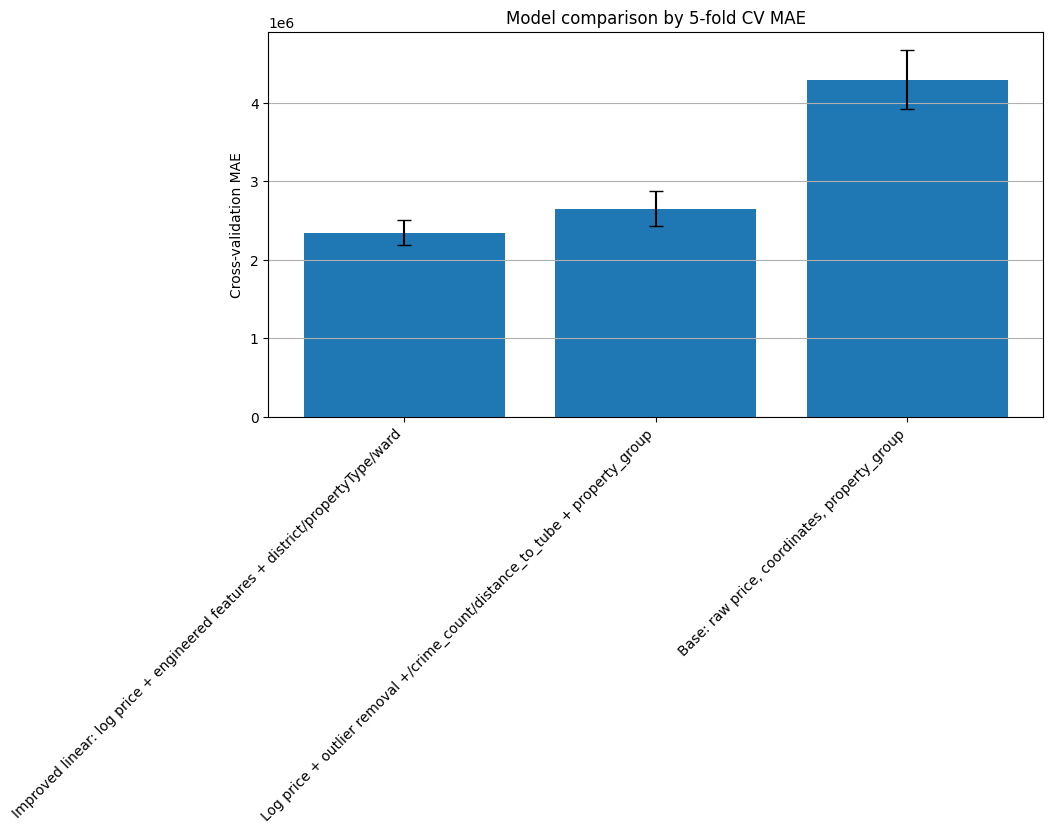

In [20]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison["model"],
    comparison["MAE"],
    yerr=comparison["MAE_std"],
    capsize=5
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Cross-validation MAE")
plt.title("Model comparison by 5-fold CV MAE")
plt.grid(axis="y")

plt.show()

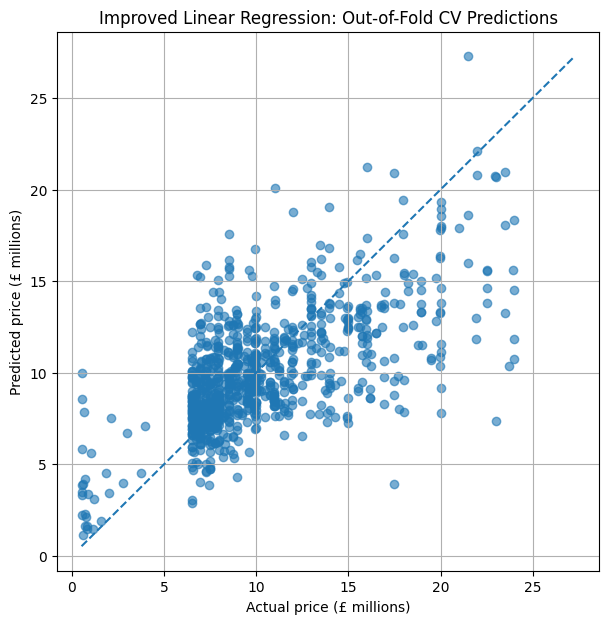

In [21]:
y_true = improved_data["y_test_price"].flatten()
y_pred = improved_predictions.flatten()

y_true_m = y_true / 1_000_000
y_pred_m = y_pred / 1_000_000

plt.figure(figsize=(7, 7))

plt.scatter(y_true_m, y_pred_m, alpha=0.6)

min_val = min(y_true_m.min(), y_pred_m.min())
max_val = max(y_true_m.max(), y_pred_m.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual price (£ millions)")
plt.ylabel("Predicted price (£ millions)")
plt.title("Improved Linear Regression: Out-of-Fold CV Predictions")
plt.grid(True)

plt.show()

In [22]:
absolute_errors = np.abs(y_true - y_pred)
errors_df = pd.DataFrame({
    "actual_price": y_true,
    "predicted_price": y_pred,
    "absolute_error": absolute_errors
})

errors_df["actual_price_m"] = errors_df["actual_price"] / 1_000_000
errors_df["predicted_price_m"] = errors_df["predicted_price"] / 1_000_000
errors_df["absolute_error_m"] = errors_df["absolute_error"] / 1_000_000

errors_df = errors_df.sort_values("absolute_error", ascending=False)

errors_df.head(10)

,actual_price,predicted_price,absolute_error,actual_price_m,predicted_price_m,absolute_error_m
189,23000000.0,7339669.5,15660330.5,23.00000,7.339670,15.660331
741,17500000.0,3931317.5,13568682.5,17.50000,3.931318,13.568682
5,23709660.0,10352657.0,13357003.0,23.70966,10.352657,13.357003
550,24000000.0,10754265.0,13245735.0,24.00000,10.754265,13.245735
8,20000000.0,7802531.0,12197469.0,20.00000,7.802531,12.197469
549,24000000.0,11824120.0,12175880.0,24.00000,11.824120,12.175880
552,20000000.0,9153071.0,10846929.0,20.00000,9.153071,10.846929
733,23500000.0,13234963.0,10265037.0,23.50000,13.234963,10.265037
182,18000000.0,7879153.5,10120846.5,18.00000,7.879154,10.120847
369,21950000.0,11855306.0,10094694.0,21.95000,11.855306,10.094694
